# 🏥 Project : Medical Insurance Cost Predictor
### Dataset: Medical Insurance Dataset (insurance.csv)
---

## 📋 Dataset Overview & Expected Target

| Feature | Description | Type |
|---------|-------------|------|
| `age` | Age of the primary beneficiary | Numerical |
| `sex` | Gender: male / female | Categorical (binary) |
| `bmi` | Body Mass Index | Numerical |
| `children` | Number of dependents covered | Numerical (discrete) |
| `smoker` | Whether the person smokes: yes / no | Categorical (binary) |
| `region` | US region: northeast / southeast / southwest / northwest | Categorical |


---
## ⚙️ Phase 1 — Environment & Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

TARGET = "charges"

### 1.1 — Load the Dataset

In [4]:
FILE_PATH = "insurance.csv"    
df = pd.read_csv(FILE_PATH)
print(df.shape)

(1338, 7)


### 1.2 — Initial Inspection

In [5]:
df.head()
# df.tail()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [8]:
df.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

---
## 📊 Phase 2 — Exploratory Data Analysis (EDA)

### 2.1 — Target Variable Distribution

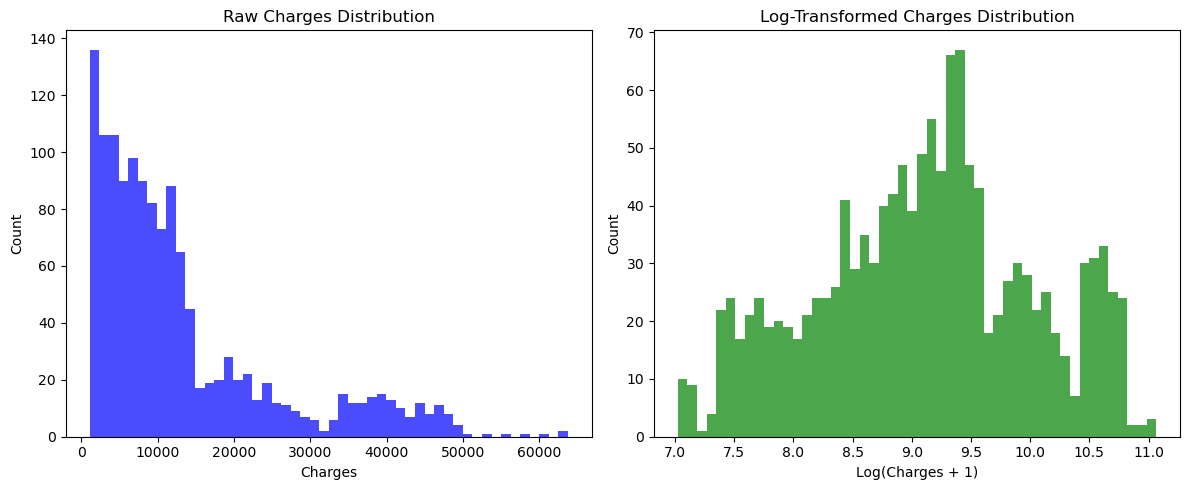

In [10]:
fig , axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df[TARGET], bins=50, color='blue', alpha=0.7)
axes[0].set_title('Raw Charges Distribution')
axes[0].set_xlabel('Charges')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df[TARGET]), bins=50, color='green', alpha=0.7)
axes[1].set_title('Log-Transformed Charges Distribution')
axes[1].set_xlabel('Log(Charges + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 2.2 — The SMOKER Effect (Pivotal Plot)

,mean,median,count
smoker,,,
no,8434.268298,7345.40530,1064
yes,32050.231832,34456.34845,274


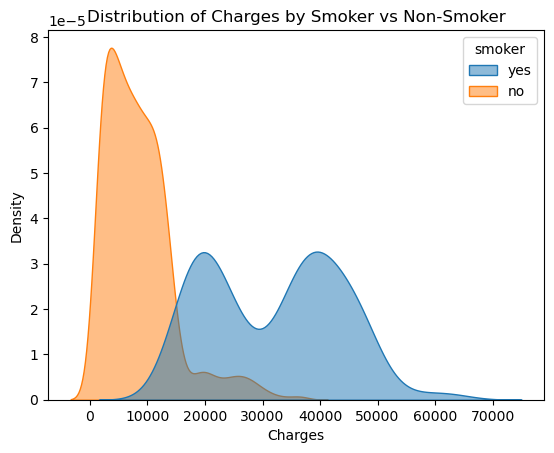

In [11]:
sns.kdeplot(data= df, x = TARGET, hue="smoker", fill=True, alpha=0.5, common_norm=False)
plt.title('Distribution of Charges by Smoker vs Non-Smoker')
plt.xlabel('Charges')
plt.ylabel('Density')
df.groupby("smoker")[TARGET].agg(["mean", "median", "count"])

### 2.3 — Correlation Heatmap

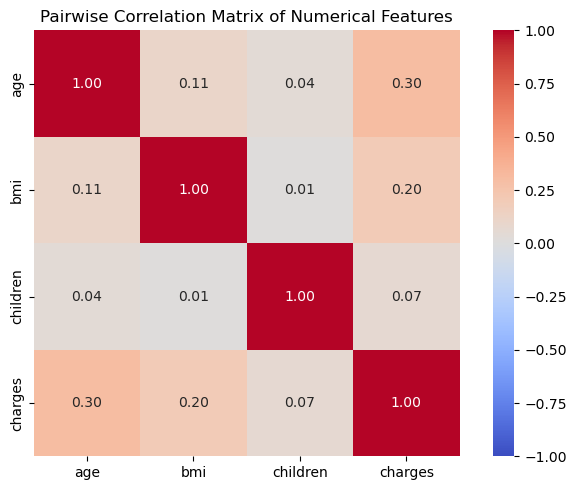

In [19]:
# df.info()
numerical_df = df.select_dtypes(include= [np.number])
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, vmin=-1, vmax=1)
plt.title("Pairwise Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

### 2.4 — Pairplot (coloured by Smoker Status)

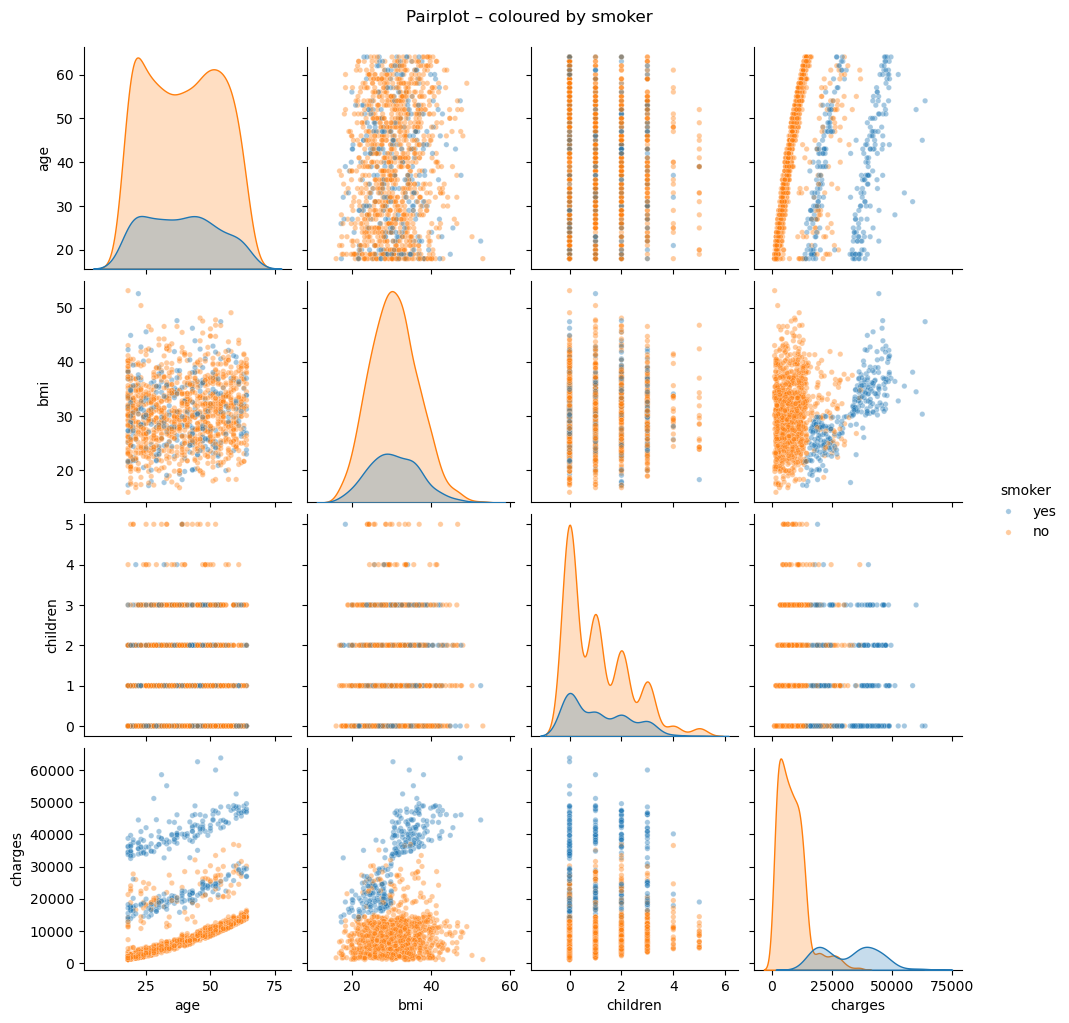

In [ ]:
sns.pairplot(df, hue="smoker", plot_kws={"alpha": 0.4, "s": 15})
plt.suptitle("Pairplot – coloured by smoker", y=1.02)
plt.show()

### 2.5 — BMI vs Charges (coloured by Smoker)

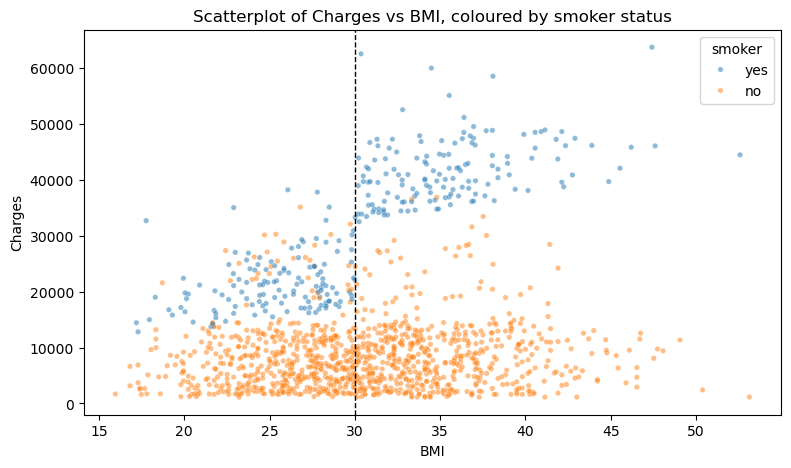

In [25]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="bmi", y=TARGET, hue="smoker", alpha=0.5, s=15)
plt.axvline(30, color="black", linestyle="--", linewidth=1)
plt.title("Scatterplot of Charges vs BMI, coloured by smoker status")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

### 2.6 — Age vs Charges (coloured by Smoker)

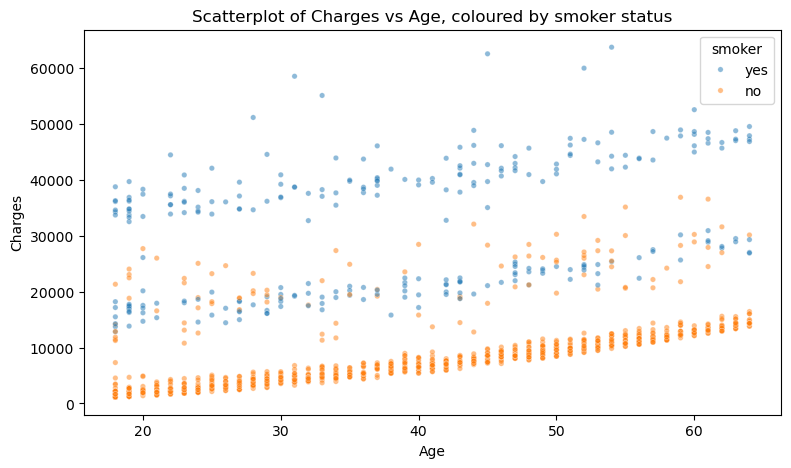

In [28]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="age", y=TARGET, hue="smoker", alpha=0.5, s=15)
plt.title("Scatterplot of Charges vs Age, coloured by smoker status")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

### 2.7 — Categorical Breakdowns (Box Plots)

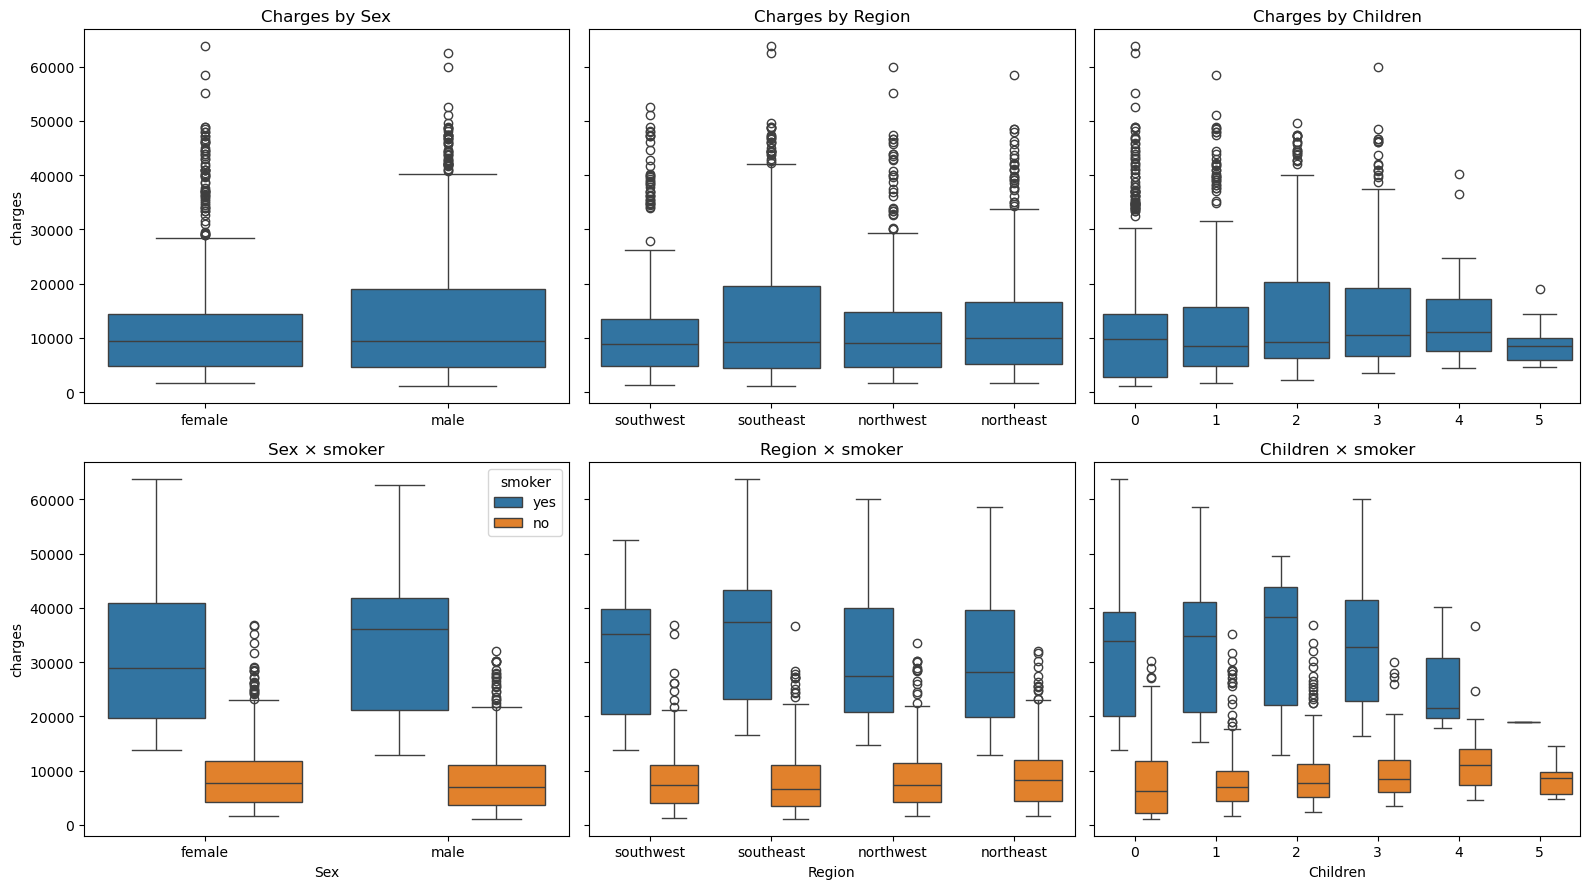

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
plots = ["sex", "region", "children"]
for i, col in enumerate(plots):
    sns.boxplot(data=df, x=col, y=TARGET, ax=axes[0, i])
    axes[0, i].set_title(f"Charges by {col.capitalize()}")
    axes[0, i].set_xlabel("")
    axes[0, i].tick_params(axis="x", rotation=0)

    sns.boxplot(data=df, x=col, y=TARGET, hue="smoker", ax=axes[1, i])
    axes[1, i].set_title(f"{col.capitalize()} × smoker")
    axes[1, i].set_xlabel(col.capitalize())
    axes[1, i].tick_params(axis="x", rotation=0)
    if i > 0:
        axes[1, i].get_legend().remove()

plt.tight_layout()
plt.show()

### 2.8 — Regional Average Charges

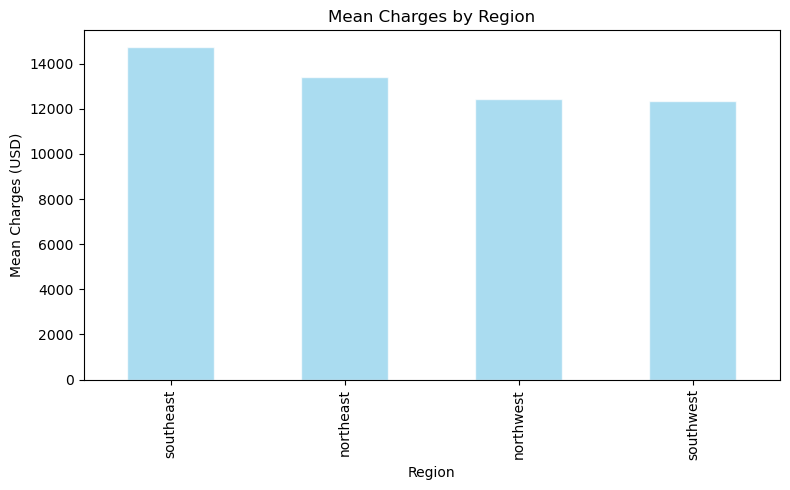

Highest − lowest region: $2,388.47 is the difference between the highest and lowest regions.
 
Smoker share by region:
smoker        no    yes
region                 
northeast  0.793  0.207
northwest  0.822  0.178
southeast  0.750  0.250
southwest  0.822  0.178 

Mean charges by region × smoker:
smoker          no       yes
region                      
northeast  9165.53  29673.54
northwest  8556.46  30192.00
southeast  8032.22  34845.00
southwest  8019.28  32269.06


In [42]:
plt.figure(figsize=(8, 5))
region_avg = df.groupby("region")[TARGET].mean().sort_values(ascending=False)
region_avg.plot(kind="bar", color="skyblue", alpha=0.7, edgecolor="white")
plt.title("Mean Charges by Region")
plt.xlabel("Region")
plt.ylabel("Mean Charges (USD)")
plt.tight_layout()
plt.show()

print(f"Highest − lowest region: ${region_avg.max() - region_avg.min():,.2f} is the difference between the highest and lowest regions.\n ")
print("Smoker share by region:")
print(pd.crosstab(df["region"], df["smoker"], normalize="index").round(3), "\n")
print("Mean charges by region × smoker:")
print(df.groupby(["region", "smoker"])[TARGET].mean().unstack().round(2))

---
## 🔧 Phase 3 — Data Preprocessing & Feature Engineering

In [ ]:
# GOAL: a working copy of the data named `df_clean`.
#
# HINTS
#   - Use the DataFrame method that returns an independent copy. Assigning
#     df_clean = df would give you a second name for the SAME object, and every
#     edit below would silently mutate your raw data.
#
# WHY
#   - Keeping `df` pristine means that when a transformation goes wrong you
#     re-run one cell instead of re-loading and re-doing everything.


### 3.1 — Handle Missing Values

In [ ]:
# GOAL: confirm (again, on df_clean) that there are no nulls; add an imputation
#       strategy only if there are.
#
# HINTS
#   - Same null-count idiom as Phase 1.
#   - If you ever DID find nulls: numeric columns are usually filled with the
#     median (robust to the skew you found in 2.1), categorical ones with the
#     mode. Never fill with a value computed from the test set.
#
# NOTE
#   - This dataset is typically complete. The cell stays in the notebook because
#     a pipeline that doesn't check is a pipeline that breaks on the next dataset.


### 3.2 — Encode Binary Categorical Variables

In [ ]:
# GOAL: `sex` and `smoker` converted from text to 0/1 integers, in place in df_clean.
#
# HINTS
#   - Both columns have exactly two values, so you don't need one-hot encoding —
#     a single 0/1 column carries all the information. The pandas Series method
#     that takes a dictionary and swaps values is the direct route.
#   - YOUR DESIGN DECISION: which value becomes 1? It doesn't change model
#     accuracy, but it flips the sign of the coefficient you'll interpret in
#     4.12 — so pick deliberately and write down your choice in a comment.
#   - You could also use LabelEncoder (it's imported), but it picks the mapping
#     alphabetically and doesn't tell you what it chose. Explicit beats implicit.
#
# CHECK YOURSELF
#   - Print the value counts afterwards. Any NaNs appearing means a string in
#     the data didn't match a key in your dictionary (watch for capitalisation
#     and stray whitespace).


### 3.3 — One-Hot Encode 'region'

In [ ]:
# GOAL: `region` replaced by indicator columns in df_clean.
#
# HINTS
#   - `region` has 4 unordered categories. Mapping them to 0/1/2/3 would tell the
#     model that southwest is "three times" northeast, which is nonsense — so
#     one-hot is the right call.
#   - pandas has a top-level function that turns categorical columns into dummy
#     indicator columns in one call; pass it the columns argument.
#   - Read about its drop_first parameter. Dropping one category avoids the
#     "dummy variable trap" (the columns summing to a constant), which makes
#     linear models' coefficients unstable. The dropped category becomes the
#     baseline every other coefficient is measured against.
#
# CHECK YOURSELF
#   - Print the column list. With drop_first you should gain 3 region columns,
#     not 4, and the original `region` column should be gone.
#   - If the new columns are True/False rather than 1/0, that's fine for sklearn,
#     but cast to int if it bothers you.


### 3.4 — Feature Engineering: Interaction Terms

In [ ]:
# GOAL: at least two new columns in df_clean that encode the interactions you
#       spotted during EDA.
#
# THE PROBLEM YOU'RE SOLVING
#   - A linear model says: effect of BMI = (some fixed number) × bmi, no matter
#     who the person is. But 2.5 showed BMI barely matters for non-smokers and
#     matters a lot for smokers. One fixed slope cannot express that.
#   - An interaction term — one feature multiplied by another — lets the model
#     apply an extra slope only when the second feature is "on".
#
# HINTS
#   - Build at minimum:
#       * bmi × smoker   (name it `bmi_smoker`)
#       * age × smoker   (name it `age_smoker`)
#     Column-wise multiplication of two Series is exactly what you'd guess.
#   - This only works because 3.2 already turned `smoker` into 0/1. For a
#     non-smoker the product collapses to 0, so the extra slope switches off.
#   - OPTIONAL: recall the curvature question from 2.6. A squared age column
#     (`age_squared`) gives a linear model a way to bend.
#   - OPTIONAL: an "obese" flag (bmi above the clinical 30 threshold) and its
#     interaction with smoker is worth an experiment once the baseline works.
#
# ASK YOURSELF
#   - Tree models (4.7, 4.8) can discover interactions on their own by splitting.
#     So who benefits more from these columns — the linear models or the trees?
#     Compare the two families in 4.10 and see whether your prediction holds.
#
# CHECK YOURSELF
#   - Print the shape and the first rows. Confirm the new columns are 0 for
#     every non-smoker row.


### 3.5 — (Optional) Target Transformation

In [ ]:
# GOAL: decide — and act on — whether to model `charges` directly or its
#       log-transformed version.
#
# HINTS
#   - Go back to your two histograms in 2.1. If the log version looked far more
#     symmetric, transforming can help models that assume roughly constant error
#     across the range (the linear family especially).
#   - Apply the numpy log-plus-one function to the target column.
#
# THE TRAP — read this twice
#   - If you transform the target, every prediction your models make comes out
#     in LOG DOLLARS. An RMSE of 0.4 log-dollars is meaningless to a human, and
#     you cannot compare it against a run where you didn't transform.
#   - Before computing metrics in 4.9, invert BOTH y_test and the predictions
#     with the numpy inverse of log1p, so your errors are back in real dollars.
#   - Miss that step and you'll "improve" your RMSE by a factor of thousands and
#     believe it. This is the single most common self-inflicted wound in this project.
#
# SUGGESTION
#   - Run the whole notebook once WITHOUT the transform, record the numbers,
#     then once WITH it. Comparing two honest runs teaches more than guessing.


---
## 🤖 Phase 4 — Model Training & Evaluation

### 4.1 — X / y Split

In [ ]:
# GOAL: `X` = every predictor column, `y` = the target column.
#
# HINTS
#   - X is df_clean with the target column dropped; y is that column on its own.
#   - Print both shapes. X must have the same number of rows as y, and one
#     fewer column than df_clean.
#
# CHECK YOURSELF
#   - Scan X's column list. Is the target — or anything derived from it —
#     still in there? That's data leakage, and it produces a suspiciously
#     perfect R² that means nothing.


### 4.2 — Train / Test Split

In [ ]:
# GOAL: X_train, X_test, y_train, y_test.
#
# HINTS
#   - train_test_split is already imported. It returns the four pieces in that
#     exact order — getting the order wrong is a classic silent bug.
#   - YOUR DECISIONS: what fraction to hold out (80/20 is conventional for a
#     dataset this small), and what random_state to fix.
#   - Fix the random_state to SOME value. Without it, every re-run reshuffles
#     and your model comparison in 4.10 compares runs, not models.
#
# CHECK YOURSELF
#   - Print all four shapes. Train rows + test rows must equal your total.


### 4.3 — (Optional) Feature Scaling

In [ ]:
# GOAL: scaled copies of the training and test features, named X_train_scaled
#       and X_test_scaled.
#
# WHO NEEDS THIS
#   - Linear / Ridge / Lasso: yes. Ridge and Lasso penalise coefficient size, so
#     a feature measured in the thousands gets penalised differently from one
#     measured in single digits. Unscaled inputs make the penalty arbitrary.
#   - Random Forest / Gradient Boosting: no. Trees split on thresholds, and a
#     threshold doesn't care about units. Feed them the raw X_train.
#
# HINTS
#   - StandardScaler is imported. It has one method that learns the statistics
#     and transforms at once, and another that only transforms.
#
# ⚠️ THE RULE YOU MUST NOT BREAK
#   - Learn the scaling statistics from the TRAINING data only, then apply them
#     to the test data. If you let the scaler see the test set, information from
#     it leaks into training and your test score stops being an honest estimate.
#   - Which method goes on which set? Answering that correctly is the whole point
#     of this cell.


### 4.4 — Baseline: Linear Regression

In [ ]:
# GOAL: a fitted LinearRegression named `lr_model` and its test-set predictions
#       named `lr_preds`.
#
# HINTS
#   - Every sklearn estimator follows the same three-step shape: construct,
#     fit on training data, predict on test data. Learn it once and every model
#     below is the same code with a different constructor.
#   - Use the SCALED features here.
#
# WHY A BASELINE
#   - This is the number every fancier model has to beat. If Gradient Boosting
#     only matches plain linear regression, the extra complexity is buying you
#     nothing — and that's a legitimate finding, not a failure.


### 4.5 — Regularised Linear: Ridge Regression

In [ ]:
# GOAL: `ridge_model` and `ridge_preds`.
#
# THE CONCEPT
#   - Ridge = linear regression + an L2 penalty on the size of the coefficients.
#     It shrinks coefficients toward zero (but never exactly to zero), which
#     tames the instability caused by correlated features — like the interaction
#     terms you built in 3.4, which are correlated with their parents by design.
#
# HINTS
#   - The only constructor argument you need is alpha, the penalty strength.
#     alpha = 0 is plain linear regression; large alpha shrinks everything hard.
#   - YOUR EXPERIMENT: try 0.1, 1.0, 10, 100 and record the test R² for each.
#     Does the curve peak somewhere in the middle, or keep getting worse?
#   - Scaled features, as in 4.4.
#
# GOING FURTHER
#   - Once the manual sweep makes sense, look up RidgeCV — it does the search
#     with cross-validation instead of you eyeballing four numbers.


### 4.6 — Regularised Linear: Lasso Regression

In [ ]:
# GOAL: `lasso_model` and `lasso_preds`.
#
# THE CONCEPT
#   - Lasso = linear regression + an L1 penalty. Unlike Ridge, it can drive
#     coefficients to EXACTLY zero, so it performs feature selection for you.
#
# HINTS
#   - Same single alpha argument. Sweep the same values as Ridge so the two are
#     comparable.
#   - Scaled features again.
#
# ASK YOURSELF
#   - After fitting, count how many coefficients are exactly zero. Which features
#     did Lasso discard?
#   - Do the survivors match what you predicted back in 2.7? If Lasso zeroed out
#     `sex` or the region dummies, your EDA instinct was right.


### 4.7 — Ensemble: Random Forest Regressor

In [ ]:
# GOAL: `rf_model` and `rf_preds`.
#
# THE CONCEPT
#   - Many decision trees, each grown on a bootstrap sample of the rows and a
#     random subset of features, averaged together. Individually noisy, jointly
#     stable. Splitting on thresholds means it captures the BMI-threshold and
#     smoker-interaction effects without you engineering them.
#
# HINTS
#   - ⚠️ Fit on the RAW X_train, not the scaled version. Trees don't need scaling,
#     and using the scaled arrays here costs you the column names you'll want
#     in 4.11.
#   - YOUR DECISIONS: n_estimators (how many trees — more is steadier and slower;
#     100 is a fine start), max_depth (None lets trees grow until pure, which on
#     ~1,300 rows will overfit; try capping it), and random_state so results
#     reproduce.
#
# ASK YOURSELF
#   - Score the model on the TRAINING set as well as the test set. A large gap
#     (say train R² 0.97 vs test 0.85) is overfitting. Lowering max_depth or
#     raising min_samples_leaf is the usual response — try it and watch the gap.


### 4.8 — Ensemble: Gradient Boosting Regressor

In [ ]:
# GOAL: `gb_model` and `gb_preds`.
#
# THE CONCEPT
#   - Where a Random Forest builds trees in parallel and averages, boosting builds
#     them in sequence: each new tree is trained on the errors the ensemble has
#     made so far. Often the strongest model on small tabular data like this.
#
# HINTS
#   - Raw (unscaled) X_train again.
#   - YOUR DECISIONS: n_estimators, learning_rate, max_depth, random_state.
#   - The key intuition: learning_rate and n_estimators trade off against each
#     other. A smaller learning rate needs more trees to reach the same place,
#     but usually generalises better. Shallow trees (depth 2–4) are normal here —
#     boosting wants many weak learners, not a few strong ones.
#
# ASK YOURSELF
#   - Try (learning_rate 0.1, 100 trees) against (0.05, 300 trees). Which wins
#     on the test set, and how much longer did it take to fit?


### 4.9 — Evaluation Helper Function

In [ ]:
# GOAL: a function `evaluate_model(name, y_true, y_pred)` that prints MSE, RMSE,
#       MAE and R², and returns them in a dict so you can build a table in 4.10.
#
# HINTS
#   - All four metrics are already imported. RMSE is just the square root of MSE
#     — numpy has that.
#   - Return something like {"Model": name, "MSE": ..., "RMSE": ..., "MAE": ...,
#     "R2": ...} so 4.10 can turn a list of these straight into a DataFrame.
#   - f-strings with format specs (thousands separators, fixed decimals) make the
#     output readable. Worth ten minutes of your time.
#
# KNOW WHAT YOU'RE PRINTING
#   - RMSE is in the same unit as the target — dollars. It punishes large errors
#     hardest, so it's sensitive to that expensive-smoker tail.
#   - MAE is the average error in dollars, treating all errors equally. If RMSE
#     is much larger than MAE, a few big misses are dominating.
#   - R² is the share of variance explained; 1.0 is perfect, 0.0 is no better
#     than always predicting the mean. It can go negative — that means worse
#     than the mean.
#   - ⚠️ If you log-transformed in 3.5, invert both arguments back to dollars
#     BEFORE calling this, or the numbers are uninterpretable.
#
# THEN
#   - Build a list called `results` and append one evaluate_model(...) call per
#     fitted model: Linear, Ridge, Lasso, Random Forest, Gradient Boosting.


### 4.10 — Model Comparison Table

In [ ]:
# GOAL: one DataFrame, one row per model, sorted best-first.
#
# HINTS
#   - Your `results` list of dicts goes straight into the DataFrame constructor.
#     Set the model name as the index, then sort by R² descending (or by RMSE
#     ascending — they should agree).
#
# ASK YOURSELF
#   - Which family won: the linear models or the trees?
#   - How much did the interaction terms from 3.4 buy the linear models? (Comment
#     them out, re-run, compare. That's a controlled experiment, and it's the
#     most valuable thing you'll do in this notebook.)
#   - Is the winner's margin large, or within the noise you'd get from a different
#     random_state? Section 4.14 is how you answer that properly.


### 4.11 — Feature Importance (Random Forest)

In [ ]:
# GOAL: a horizontal bar chart of the Random Forest's feature importances,
#       sorted, largest at the top.
#
# HINTS
#   - A fitted forest exposes its importances as an attribute (an array in the
#     same order as the training columns). Wrap it in a pandas Series indexed by
#     X_train.columns so the bars are labelled — this is exactly why 4.7 used the
#     raw DataFrame instead of a scaled numpy array.
#   - Sort the Series, take the top n, and use .plot with a horizontal bar kind.
#
# ASK YOURSELF
#   - Is `smoker` at the top? Does the ranking match what your EDA predicted?
#   - Where did your engineered interaction columns land? If `bmi_smoker` ranks
#     high, note the subtlety: the forest could have found that interaction on
#     its own, so a high rank doesn't prove the feature was necessary — only that
#     the model used it once offered.
#   - Caveat worth knowing: impurity-based importances are biased toward
#     high-cardinality features. For a more trustworthy ranking, look up
#     sklearn's permutation_importance.


### 4.12 — Coefficient Inspection (Linear Model)

In [ ]:
# GOAL: a horizontal bar chart of the linear model's coefficients, sorted, with
#       a vertical line marking zero.
#
# HINTS
#   - A fitted linear model exposes its coefficients as an attribute. Same
#     Series-indexed-by-column-names trick as 4.11.
#   - Add a vertical line at x = 0 so positive and negative effects read clearly.
#
# HOW TO INTERPRET
#   - Because you scaled in 4.3, each coefficient means: the change in predicted
#     charges for a one-standard-deviation increase in that feature, holding the
#     rest fixed. That shared unit is what makes them comparable to each other.
#   - Sign matters. Check that `smoker` points the direction 2.2 said it should —
#     and remember your 0/1 choice from 3.2 determines that sign.
#
# ASK YOURSELF
#   - Which coefficient is largest in absolute value? Does it agree with the
#     forest's top feature in 4.11?
#   - If the two disagree, that's not an error — it's the difference between a
#     model that must be linear and one that can carve the space into regions.
#     Can you explain which you'd trust and why?


### 4.13 — Actual vs Predicted Plot

In [ ]:
# GOAL: a scatter of actual test values (x) against your best model's
#       predictions (y), with a diagonal reference line.
#
# HINTS
#   - The diagonal is the line y = x — where every point would sit if predictions
#     were perfect. Build its endpoints from the combined min and max of both
#     arrays so the line spans the data, and draw it dashed.
#   - Equal axis limits make the diagonal read at 45°, which is what your eye
#     wants here.
#
# HOW TO READ IT
#   - Points ABOVE the line: the model over-predicted. BELOW: under-predicted.
#   - Look at the expensive end (high actual charges). Does the cloud drift
#     systematically below the line? That's the model under-predicting the most
#     expensive patients — the hardest and most consequential errors in this
#     dataset. Almost every model here does it to some degree.
#
# GOING FURTHER
#   - Plot the residuals (actual − predicted) against the predictions. If the
#     spread widens as predictions grow, that's heteroscedasticity, and it's the
#     statistical argument for the log transform in 3.5.


### 4.14 — Cross-Validation

In [ ]:
# GOAL: 5-fold cross-validated R² for your best model — the mean and the
#       standard deviation across folds.
#
# HINTS
#   - cross_val_score is imported. It takes an UNFITTED estimator, the full X and
#     y, a cv value, and a scoring string; it handles the splitting and refitting
#     for you and hands back one score per fold.
#   - Report mean ± std, not just the mean. The std is the point of the exercise.
#
# WHY THIS IS THE LAST WORD
#   - Your single 80/20 test score depends on which rows happened to land in the
#     test set. With ~1,300 rows and a heavy right tail, that luck is worth real
#     R² points. Cross-validation averages over five different splits.
#   - Now revisit 4.10: if two models were 0.01 apart on R² but the fold-to-fold
#     std is 0.03, you cannot claim one beat the other. Say so in your write-up —
#     knowing when a difference isn't real is a genuinely senior skill.
#
# ⚠️ CAUTION
#   - If you scaled features, doing it before cross-validation leaks information
#     across folds. The correct fix is to wrap the scaler and the model in an
#     sklearn Pipeline and pass the pipeline to cross_val_score. Look it up —
#     it's the natural next thing to learn after this notebook.


---
## ✅ Wrap-Up

You're done when you can answer these without scrolling up:

1. Which single feature dominates `charges`, and what evidence convinced you?
2. Why did you build interaction terms, and which model family actually needed them?
3. Which model won, by how much, and is that margin bigger than the cross-validation noise?
4. Where does your best model fail hardest, and why does that matter for an insurer?

If a question is hard to answer, the fix is usually a plot you skipped — not a model you haven't tried yet.

### Optional extensions
- Wrap preprocessing and the model in an sklearn **Pipeline**, then tune with `GridSearchCV`.
- Add **XGBoost** or **LightGBM** and see whether they beat Gradient Boosting on 1,300 rows.
- Explain individual predictions with **SHAP** values.
- Write a `predict_charge(age, sex, bmi, children, smoker, region)` helper that applies the same preprocessing to one new person and returns a dollar estimate.